In [2]:
import glob, joblib, pathlib
from tqdm import tqdm

import numpy as np
import pandas as pd

import sklearn as sk
import sklearn.ensemble
import sklearn.feature_selection
import matplotlib.pyplot as plt

import tabpfn as tfn

import dotenv
dotenv.load_dotenv() 

seed=99

/opt/homebrew/anaconda3/envs/tabPFN/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data_file = '../data/all_matchup_data.csv'
df = pd.read_csv(data_file, parse_dates=['date'])
df

,Unnamed: 0,Rrs_412,Rrs_443,Rrs_490,Rrs_510,Rrs_560,Rrs_665,chlor_a,kd_490,bathymetric_depth,...,Allo,But,Fuco,Hex,Peri,Zea,date,lat,lon,Depth_P
0,5021,0.009018,0.007264,0.005893,0.003996,0.002123,0.000206,0.273823,0.046247,4491.555556,...,0.00100,0.00500,0.00400,0.02300,0.00200,0.10200,1997-10-01,8.8233,-21.7333,7.0
1,5030,0.009405,0.007606,0.005631,0.003257,0.001568,0.000086,0.135375,0.034994,4106.666667,...,0.00000,0.00400,0.00500,0.01400,0.00100,0.06000,1997-10-01,5.0392,-23.2611,7.0
2,5032,0.002912,0.002769,0.002817,0.002732,0.001887,0.000126,0.842282,0.100491,836.444444,...,0.03849,0.03783,0.15120,0.19872,0.17901,0.03225,1997-11-01,44.1400,-58.1600,1.0
3,5033,0.003533,0.003304,0.003152,0.003114,0.002256,0.000273,0.918942,0.109454,72.000000,...,0.03013,0.03147,0.24192,0.22017,0.12744,0.02656,1997-11-01,44.4800,-58.5100,1.0
4,5034,0.005035,0.004159,0.003105,0.002764,0.001416,0.000237,0.449651,0.066610,250.666667,...,0.01205,0.01937,0.09658,0.17388,0.08370,0.01027,1997-11-01,44.8100,-58.8500,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8321,33629,0.006211,0.011783,0.018698,0.021096,0.027422,0.010818,4.720951,0.946189,52.666667,...,0.02000,0.01600,0.58800,0.02800,0.00000,0.11600,2021-04-28,-12.4000,130.7680,18.0
8322,33630,0.006211,0.011783,0.018698,0.021096,0.027422,0.010818,4.720951,0.946189,52.666667,...,0.01400,0.00000,0.38600,0.02900,0.00000,0.09000,2021-04-28,-12.4000,130.7680,0.0
8323,33631,0.006211,0.011783,0.018698,0.021096,0.027422,0.010818,4.720951,0.946189,52.666667,...,0.01500,0.00000,0.34300,0.02900,0.00000,0.08600,2021-04-28,-12.4000,130.7680,16.0
8324,33632,0.006211,0.011783,0.018698,0.021096,0.027422,0.010818,4.720951,0.946189,52.666667,...,0.01800,0.00000,0.33300,0.02800,0.00000,0.08400,2021-04-28,-12.4000,130.7680,0.0


In [4]:
df = df.rename({'TChl_a':'TChla'})
df.columns

Index(['Unnamed: 0', 'Rrs_412', 'Rrs_443', 'Rrs_490', 'Rrs_510', 'Rrs_560',
       'Rrs_665', 'chlor_a', 'kd_490', 'bathymetric_depth', 'TChl_a', 'TChlb',
       'Allo', 'But', 'Fuco', 'Hex', 'Peri', 'Zea', 'date', 'lat', 'lon',
       'Depth_P'],
      dtype='object')

In [5]:
INPUT_VARS = {'all':[v for v in df.columns if 'Rrs' in v] + ['chlor_a', 'kd_490',],
              'all_FM':[v for v in df.columns if 'Rrs' in v] + ['chlor_a', 'kd_490',],
             'Rrs':[v for v in df.columns if 'Rrs' in v],
             'chl':['chlor_a']}
OUTPUT_VARS_ = [ 'TChlb', 'Allo', 'But', 'Fuco', 'Hex', 'Peri', 'Zea']


In [6]:
INPUT_VARS

{'all': ['Rrs_412',
  'Rrs_443',
  'Rrs_490',
  'Rrs_510',
  'Rrs_560',
  'Rrs_665',
  'chlor_a',
  'kd_490'],
 'all_FM': ['Rrs_412',
  'Rrs_443',
  'Rrs_490',
  'Rrs_510',
  'Rrs_560',
  'Rrs_665',
  'chlor_a',
  'kd_490'],
 'Rrs': ['Rrs_412', 'Rrs_443', 'Rrs_490', 'Rrs_510', 'Rrs_560', 'Rrs_665'],
 'chl': ['chlor_a']}

In [8]:
dv = df[OUTPUT_VARS_]
df[OUTPUT_VARS_] = dv.where(~dv.isin((0.005, 0.004, 0.003, 0.002, 0.001, 0)), other=np.nan)
df[OUTPUT_VARS_]

,TChlb,Allo,But,Fuco,Hex,Peri,Zea
0,NaN,NaN,NaN,NaN,0.02300,NaN,0.10200
1,NaN,NaN,NaN,NaN,0.01400,NaN,0.06000
2,0.08280,0.03849,0.03783,0.15120,0.19872,0.17901,0.03225
3,0.21600,0.03013,0.03147,0.24192,0.22017,0.12744,0.02656
4,0.02808,0.01205,0.01937,0.09658,0.17388,0.08370,0.01027
...,...,...,...,...,...,...,...
8321,0.05900,0.02000,0.01600,0.58800,0.02800,NaN,0.11600
8322,0.04000,0.01400,NaN,0.38600,0.02900,NaN,0.09000
8323,0.03900,0.01500,NaN,0.34300,0.02900,NaN,0.08600
8324,0.05700,0.01800,NaN,0.33300,0.02800,NaN,0.08400


In [9]:
OUTPUT_VARS = [var+'_log' for var in OUTPUT_VARS_]
for var in OUTPUT_VARS_:
    df[var+'_log'] = np.log10(df[var])
df = df.replace([np.inf, -np.inf], np.nan)
df

,Unnamed: 0,Rrs_412,Rrs_443,Rrs_490,Rrs_510,Rrs_560,Rrs_665,chlor_a,kd_490,bathymetric_depth,...,lat,lon,Depth_P,TChlb_log,Allo_log,But_log,Fuco_log,Hex_log,Peri_log,Zea_log
0,5021,0.009018,0.007264,0.005893,0.003996,0.002123,0.000206,0.273823,0.046247,4491.555556,...,8.8233,-21.7333,7.0,NaN,NaN,NaN,NaN,-3.772261,NaN,-2.282782
1,5030,0.009405,0.007606,0.005631,0.003257,0.001568,0.000086,0.135375,0.034994,4106.666667,...,5.0392,-23.2611,7.0,NaN,NaN,NaN,NaN,-4.268698,NaN,-2.813411
2,5032,0.002912,0.002769,0.002817,0.002732,0.001887,0.000126,0.842282,0.100491,836.444444,...,44.1400,-58.1600,1.0,-2.491327,-3.257357,-3.274653,-1.889152,-1.615858,-1.720314,-3.434237
3,5033,0.003533,0.003304,0.003152,0.003114,0.002256,0.000273,0.918942,0.109454,72.000000,...,44.4800,-58.5100,1.0,-1.532477,-3.502234,-3.458721,-1.419148,-1.513355,-2.060110,-3.628349
4,5034,0.005035,0.004159,0.003105,0.002764,0.001416,0.000237,0.449651,0.066610,250.666667,...,44.8100,-58.8500,1.0,-3.572698,-4.418691,-3.944030,-2.337384,-1.749390,-2.480516,-4.578528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8321,33629,0.006211,0.011783,0.018698,0.021096,0.027422,0.010818,4.720951,0.946189,52.666667,...,-12.4000,130.7680,18.0,-2.830218,-3.912023,-4.135167,-0.531028,-3.575551,NaN,-2.154165
8322,33630,0.006211,0.011783,0.018698,0.021096,0.027422,0.010818,4.720951,0.946189,52.666667,...,-12.4000,130.7680,0.0,-3.218876,-4.268698,NaN,-0.951918,-3.540459,NaN,-2.407946
8323,33631,0.006211,0.011783,0.018698,0.021096,0.027422,0.010818,4.720951,0.946189,52.666667,...,-12.4000,130.7680,16.0,-3.244194,-4.199705,NaN,-1.070025,-3.540459,NaN,-2.453408
8324,33632,0.006211,0.011783,0.018698,0.021096,0.027422,0.010818,4.720951,0.946189,52.666667,...,-12.4000,130.7680,0.0,-2.864704,-4.017384,NaN,-1.099613,-3.575551,NaN,-2.476938


In [10]:
# Generated data from angus matchup pigment-prediction notebook
TEST_YEARS = [2002,2007,2012,2017]

df['train'] = True
df.loc[df.date.dt.year.isin(TEST_YEARS),'train'] = False

test_df = df.loc[~df.train]
train_df = df.loc[df.train]
train_df.shape, test_df.shape

((6625, 30), (1701, 30))

In [11]:
def plot_results(ax, y, y_pred, y_test,y_testpred, var, title, not_log=False, mask_nan=False):
    if not_log:
        y_pred = np.log10(y_pred)
        y_testpred = np.log10(y_testpred)

    if mask_nan:
        nan_mask = ~(y.isna()+y_pred.isna())
        y = y[nan_mask]
        y_pred = y_pred[nan_mask]

        nan_mask_test = ~(y_test.isna()+y_testpred.isna())
        y_test = y_test[nan_mask_test]
        y_testpred = y_testpred[nan_mask_test]
        
    trainstr = f"Train (R$^2$={sk.metrics.r2_score(y, y_pred):.2}, N={y.shape[0]})"
    teststr  = f"Test (R$^2$={sk.metrics.r2_score(y_test, y_testpred):.2}, N={y_test.shape[0]})"
    ax.scatter(10**(y), 10**(y_pred), 5, label=trainstr, alpha=0.7, linewidths=0)
    ax.scatter(10**(y_test), 10**(y_testpred), 5, label=teststr, alpha=0.7, linewidths=0)
    
    ax.axline((0,0), (1,1), color='r', linewidth=0.5)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel(f'Recorded {var} Values')
    ax.set_ylabel(f'Predicted {var} Values')
    ax.legend()
    return sk.metrics.r2_score(y_test, y_testpred)

In [13]:
models = {r:{} for r in INPUT_VARS.keys()}
results = {r:{} for r in INPUT_VARS.keys()}
scores = {r:{} for r in INPUT_VARS.keys()}

for exp_run,IN_VARS in INPUT_VARS.items():
    for var in tqdm(OUTPUT_VARS):
        train_df_ = train_df.loc[(~train_df[var].isna())]
        test_df_ = test_df.loc[~test_df[var].isna()]
        X,y = train_df_[IN_VARS],train_df_[var]
        Xt,yt = test_df_[IN_VARS],test_df_[var]
    
        # # USE PRETRAINED MODELS
        if exp_run == 'all_FM':
            models[f'{exp_run}'][var] = tfn.TabPFNRegressor().fit(X,y)
        else:
            models[exp_run][var] = sk.ensemble.RandomForestRegressor(n_jobs=-1, n_estimators=200, max_samples=0.8).fit(X,y)
            
        df[f'{var.split('_')[0]}_{exp_run}'] = 10**(models[exp_run][var].predict(df[IN_VARS]))
        

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:01<00:00,  5.73it/s]


In [14]:
df

,Unnamed: 0,Rrs_412,Rrs_443,Rrs_490,Rrs_510,Rrs_560,Rrs_665,chlor_a,kd_490,bathymetric_depth,...,Hex_Rrs,Peri_Rrs,Zea_Rrs,TChlb_chl,Allo_chl,But_chl,Fuco_chl,Hex_chl,Peri_chl,Zea_chl
0,5021,0.009018,0.007264,0.005893,0.003996,0.002123,0.000206,0.273823,0.046247,4491.555556,...,0.028224,0.011111,0.055394,0.043155,0.006778,0.027736,0.032811,0.037169,0.006849,0.060406
1,5030,0.009405,0.007606,0.005631,0.003257,0.001568,0.000086,0.135375,0.034994,4106.666667,...,0.018366,0.003849,0.057777,0.014616,0.005362,0.010796,0.007584,0.017854,0.004119,0.054294
2,5032,0.002912,0.002769,0.002817,0.002732,0.001887,0.000126,0.842282,0.100491,836.444444,...,0.135988,0.081165,0.024669,0.083430,0.025749,0.021521,0.099690,0.099707,0.061812,0.039067
3,5033,0.003533,0.003304,0.003152,0.003114,0.002256,0.000273,0.918942,0.109454,72.000000,...,0.189964,0.066614,0.023412,0.192232,0.024802,0.019473,0.231073,0.131423,0.060698,0.018324
4,5034,0.005035,0.004159,0.003105,0.002764,0.001416,0.000237,0.449651,0.066610,250.666667,...,0.097324,0.037275,0.015376,0.022624,0.012245,0.020549,0.079275,0.109255,0.024491,0.014210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8321,33629,0.006211,0.011783,0.018698,0.021096,0.027422,0.010818,4.720951,0.946189,52.666667,...,0.025536,0.019646,0.094765,0.047281,0.017885,0.014253,0.441028,0.025724,0.046841,0.094614
8322,33630,0.006211,0.011783,0.018698,0.021096,0.027422,0.010818,4.720951,0.946189,52.666667,...,0.025536,0.019646,0.094765,0.047281,0.017885,0.014253,0.441028,0.025724,0.046841,0.094614
8323,33631,0.006211,0.011783,0.018698,0.021096,0.027422,0.010818,4.720951,0.946189,52.666667,...,0.025536,0.019646,0.094765,0.047281,0.017885,0.014253,0.441028,0.025724,0.046841,0.094614
8324,33632,0.006211,0.011783,0.018698,0.021096,0.027422,0.010818,4.720951,0.946189,52.666667,...,0.025536,0.019646,0.094765,0.047281,0.017885,0.014253,0.441028,0.025724,0.046841,0.094614


In [39]:
# df.to_parquet('../data/all_matchup_data_predicted_abilation.pq')
df = pd.read_parquet('../data/all_matchup_data_predicted_abilation.pq')

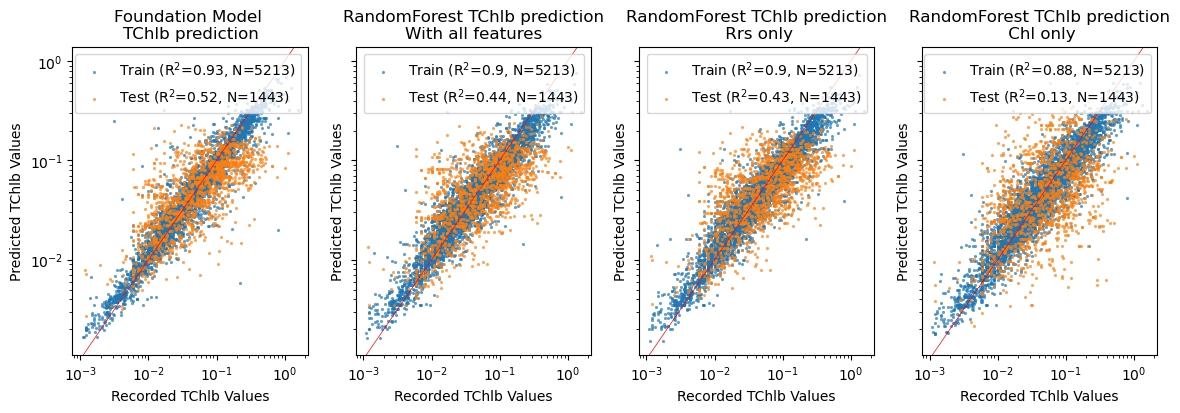

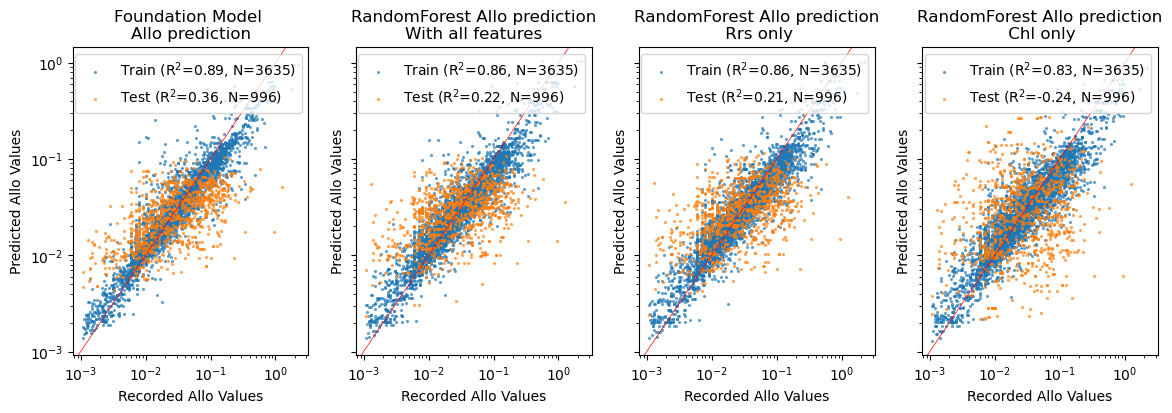

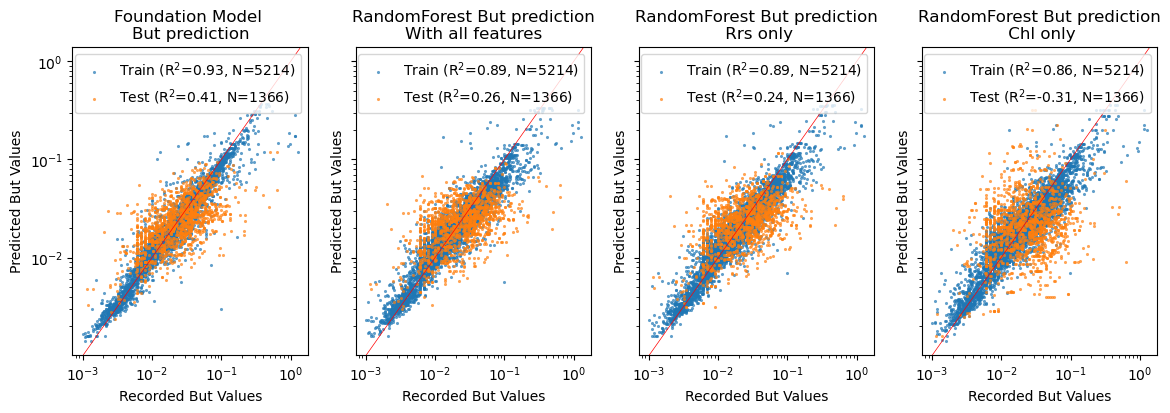

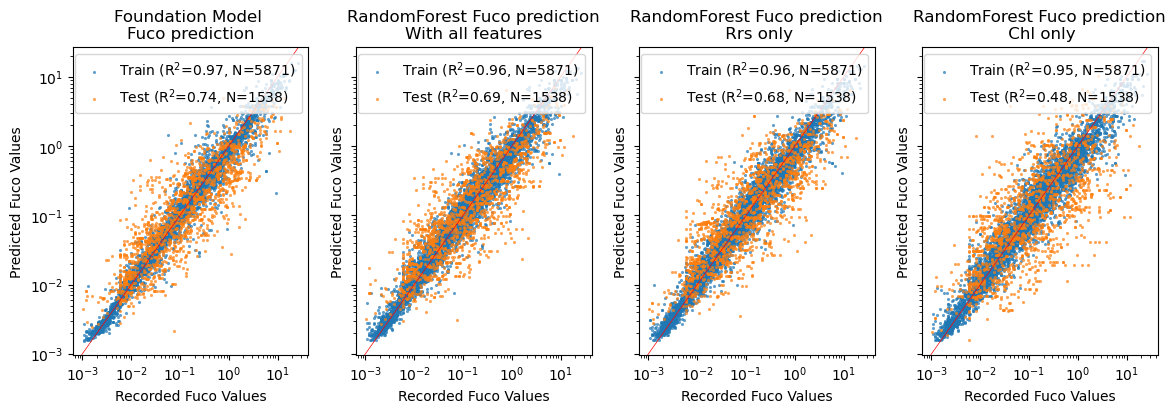

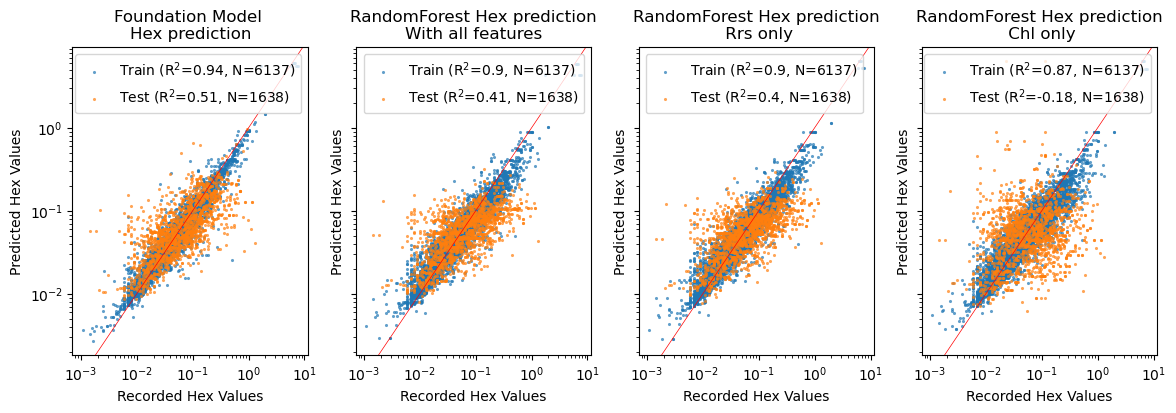

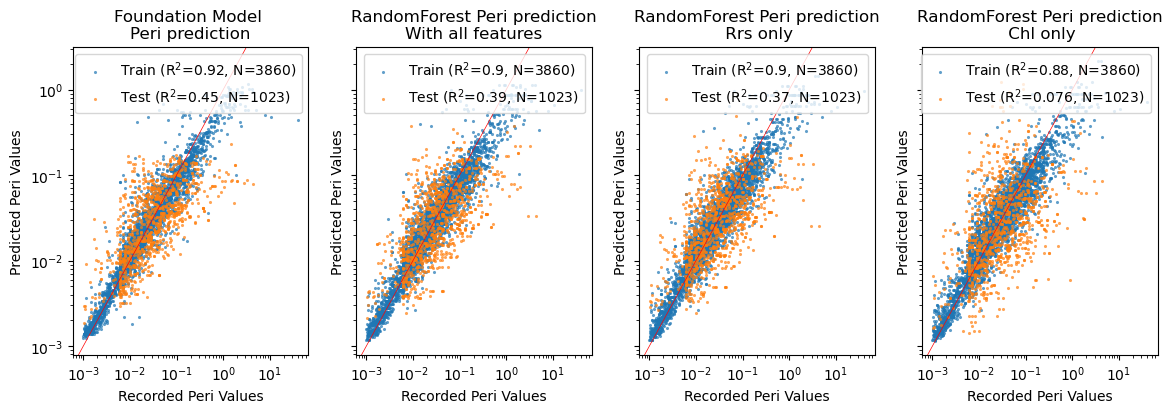

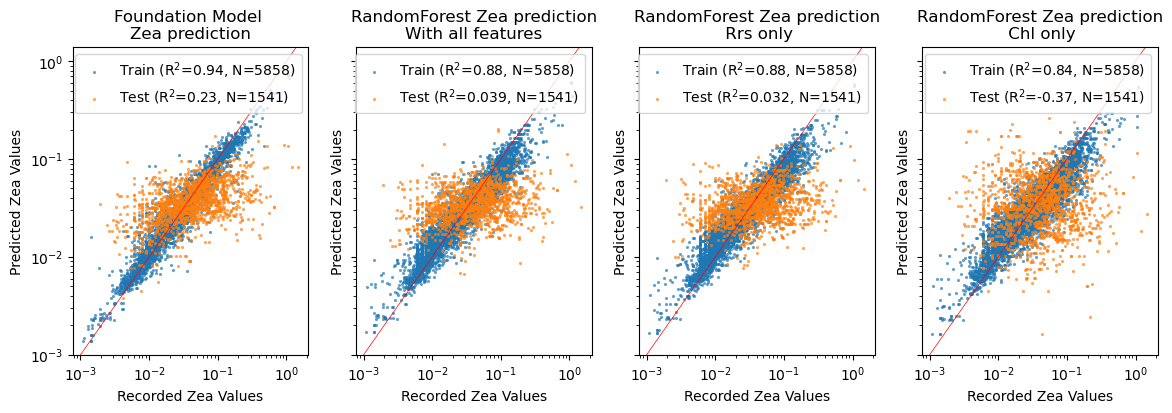

In [38]:
test_df = df.loc[~df.train]
train_df = df.loc[df.train]

for var in (OUTPUT_VARS):
    f, (ax0, ax1, ax2, ax3) = plt.subplots(1, 4, sharey=True, figsize=(14,4))
    scores['all_FM'][var] = plot_results(ax0, train_df[var], train_df[f'{var.split('_')[0]}_all_FM'], 
                                     test_df[var], test_df[f'{var.split('_')[0]}_all_FM'],
                                     var.split('_')[0], f'Foundation Model \n{var.split('_')[0]} prediction',
                                     not_log=True, mask_nan=True)

    scores['all'][var] = plot_results(ax1, train_df[var], train_df[f'{var.split('_')[0]}_all'], 
                                     test_df[var], test_df[f'{var.split('_')[0]}_all'], 
                                     var.split('_')[0], f'RandomForest {var.split('_')[0]} prediction\nWith all features',
                                     not_log=True, mask_nan=True)

    scores['Rrs'][var] = plot_results(ax2, train_df[var], train_df[f'{var.split('_')[0]}_Rrs'], 
                                     test_df[var], test_df[f'{var.split('_')[0]}_Rrs'], 
                                     var.split('_')[0], f'RandomForest {var.split('_')[0]} prediction\n Rrs only',
                                     not_log=True, mask_nan=True)
        
    scores['chl'][var] = plot_results(ax3, train_df[var], train_df[f'{var.split('_')[0]}_chl'], 
                                     test_df[var], test_df[f'{var.split('_')[0]}_chl'], 
                                     var.split('_')[0], f'RandomForest {var.split('_')[0]} prediction\n Chl only',
                                     not_log=True, mask_nan=True)

    plt.savefig(f'fig/comparison__{var}.png', bbox_inches="tight")
    plt.show()
    # break

In [ ]:
base_model_path = pathlib.Path('models')

for exp_name in models.keys():
    for model_name in models[exp_name].keys():
        model_path = base_model_path / (f'{model_name}_{exp_name}')
        with open(model_path.with_suffix('.jlsk'), "wb") as f:
            joblib.dump(models[exp_name][model_name], f, protocol=5)

In [ ]:
base_model_path = pathlib.Path('models')

for model_class in model:
    for pred_var in model[model_class]:
        model_path = base_model_path / f'{model_class}_{pred_var}'
        if 'tabfm' in model_class:
            model[model_class][pred_var].save_fit_state(model_path.with_suffix('.tabpfn_fit'))
        else:
            with open(model_path.with_suffix('.jlsk'), "wb") as f:
                joblib.dump(model[model_class][pred_var], f, protocol=5)

In [ ]:
pd.DataFrame(scores)

In [ ]:
df_scores = pd.DataFrame(scores)
df_scores.index = df_scores.index.str.removesuffix('_log')
df_scores.plot(kind='bar')
plt.ylabel('$R^2$ Score')
plt.savefig(f'fig/comparison_r2_scores.png', bbox_inches="tight")

In [ ]:
(df_scores['all'] - df_scores['chl']).plot(kind='bar')
plt.ylabel('$\Delta R^2$')
plt.savefig(f'fig/r2_improve.png', bbox_inches="tight")

In [ ]:
train_df.to_parquet('../data/train_predicted_abilation.pkl')
test_df.to_parquet('../data/test_predicted_abilation.pkl')

# Make Metrics

In [40]:
import sklearn.metrics
from validation_code import *


In [63]:
pigments = [
    "TChlb",
    "Allo",
    "But",
    "Fuco",
    "Hex",
    "Peri",
    "Zea"
]

results = []


In [ ]:
for pigment in pigments:

    for model_name in INPUT_VARS.keys():

        test_df[f"{pigment}_{model_name}_log"] = np.log10(test_df[f"{pigment}_{model_name}"])
        test_df_ = test_df[[f"{pigment}_log",f"{pigment}_{model_name}_log"]].dropna()
        train_n = train_df[[f"{pigment}_log",f"{pigment}_{model_name}"]].dropna().shape[0]
        in_situ, model = np.array(test_df_[f"{pigment}_log"]), np.array(test_df_[f"{pigment}_{model_name}_log"])
        
        n, r, p, bias, rmsd, cp_rmsd = stat_metrics(in_situ, model, log_transformed=False)
        s, i, r2 = type2_regression(in_situ, model, r)
        R2 = sklearn.metrics.r2_score(in_situ, model)


        results.append({
            "Pigment": pigment,
            "Model": model_name.replace("_log", ""),
            "train_n": train_n,
            "test_n": n,
            "r": r,
            "bias": bias,
            "RSMD": rmsd,
            "CP-RSMD": cp_rmsd,
            "R2": R2,
        })

In [71]:
print(pd.DataFrame(results).to_latex(index=False,float_format="%.3f"))

\begin{tabular}{llrrrrrrr}
\toprule
Pigment & Model & train_n & test_n & r & bias & RSMD & CP-RSMD & R2 \\
\midrule
TChlb & all & 5213 & 1443 & 0.645 & -0.043 & 0.843 & 0.842 & 0.437 \\
TChlb & all_FM & 5213 & 1443 & 0.716 & -0.043 & 0.780 & 0.779 & 0.519 \\
TChlb & Rrs & 5213 & 1443 & 0.640 & -0.031 & 0.848 & 0.847 & 0.431 \\
TChlb & chl & 5213 & 1443 & 0.498 & -0.081 & 1.049 & 1.045 & 0.129 \\
Allo & all & 3635 & 996 & 0.476 & 0.044 & 1.031 & 1.030 & 0.221 \\
Allo & all_FM & 3635 & 996 & 0.601 & -0.030 & 0.931 & 0.931 & 0.365 \\
Allo & Rrs & 3635 & 996 & 0.472 & 0.049 & 1.038 & 1.037 & 0.210 \\
Allo & chl & 3635 & 996 & 0.255 & -0.024 & 1.302 & 1.302 & -0.243 \\
But & all & 5214 & 1366 & 0.496 & -0.029 & 0.748 & 0.747 & 0.259 \\
But & all_FM & 5214 & 1366 & 0.630 & -0.008 & 0.669 & 0.669 & 0.407 \\
But & Rrs & 5214 & 1366 & 0.483 & -0.012 & 0.755 & 0.755 & 0.244 \\
But & chl & 5214 & 1366 & 0.161 & -0.100 & 0.996 & 0.991 & -0.314 \\
Fuco & all & 5871 & 1538 & 0.829 & -0.021 & 1.052 &